# 1) Spin-the-Wheel Study Task Picker

This notebook builds a very small, engaging Python "agent" using the GAME structure:

- G — Goals: what success looks like and simple rules
- A — Actions: the tools the agent can call (plain Python functions)
- M — Memory: small persistent state (saved to a JSON file)
- E — Environment: executes tools and returns feedback to the agent loop

Learning objective: Students understand the agent loop (decide -> act -> observe -> repeat) with minimal coding.

Tip for class demos: If the agent uses waiting/timers, enable DEMO_MODE=True to shorten waits.


## G — Goals

Help a student start quickly by randomly picking one 10-minute study task and showing a simple challenge.

## Simple rules (policy)

- Pick one task per loop.
- Give a 10-minute challenge.
- Track pick counts in memory (JSON).

## How to run

1. Run all cells top-to-bottom.
2. When the agent loop starts, interact in the notebook input prompts.
3. Stop anytime by typing: `stop` (or `exit`, `quit`).


In [9]:
from __future__ import annotations
import json, os, random, time
from dataclasses import dataclass
from typing import Any, Dict, List
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

def should_stop(text: str) -> bool:
    return text.strip().lower() in {"stop", "exit", "quit", "end", "bye"}

@dataclass
class Action:
    tool_name: str
    args: Dict[str, Any] = None

    def __post_init__(self):
        if self.args is None:
            self.args = {}

class Tools:
    @staticmethod
    def notify(message: str) -> str:
        print(f"\n[Agent] {message}")
        return "ok"

    @staticmethod
    def ask(prompt: str) -> str:
        return input(f"\n[You] {prompt}\n> ").strip()

    @staticmethod
    def load_memory(path: str) -> Dict[str, Any]:
        if os.path.exists(path):
            try:
                with open(path, "r", encoding="utf-8") as f:
                    return json.load(f)
            except:
                return {}
        return {}

    @staticmethod
    def save_memory(path: str, data: Dict[str, Any]) -> str:
        try:
            with open(path, "w", encoding="utf-8") as f:
                json.dump(data, f, indent=2)
            return "saved"
        except:
            return "save failed"

class Environment:
    def __init__(self, memory_path: str):
        self.memory_path = memory_path

    def execute(self, action: Action, memory: Dict[str, Any]) -> Dict[str, Any]:
        if action.tool_name == "notify":
            Tools.notify(str(action.args.get("message", "")))
            return {"result": "notified", "memory": memory}

        if action.tool_name == "ask":
            ans = Tools.ask(str(action.args.get("prompt", "")))
            return {"result": ans, "memory": memory}

        if action.tool_name == "load_memory":
            loaded = Tools.load_memory(self.memory_path)
            return {"result": "loaded", "memory": loaded}

        if action.tool_name == "save_memory":
            Tools.save_memory(self.memory_path, memory)
            return {"result": "saved", "memory": memory}

        if action.tool_name == "terminate":
            return {"result": "terminated", "memory": memory}

        return {"result": "unknown_tool", "memory": memory}

### Addition: Task management functions😁

In [11]:
from collections import defaultdict

def show_tasks(memory):
    tasks = memory.get("tasks", TASKS_DEFAULT.copy())
    fav = memory.get("favorites", set())
    hate = memory.get("hated", set())
    
    print("\nCurrent tasks:")
    for t in tasks:
        tag = ""
        if t in fav: tag = "⭐ favorite"
        if t in hate: tag = "💀 hated"
        print(f"  • {t} {tag}")
    print()

TASKS_DEFAULT = [
    "Revise last lecture notes",
    "Solve 2 easy problems",
    "Rewrite one concept in your own words",
    "Make 5 flashcards",
    "Refactor one function name + variables",
    "Watch one short explanation video (max 10 min)",
    "Teach the concept to an imaginary friend",
]

def manage_tasks(memory: dict, command: str) -> str:
    tasks     = memory.setdefault("tasks", TASKS_DEFAULT.copy())
    favorites = memory.setdefault("favorites", set())
    hated     = memory.setdefault("hated", set())

    parts = command.strip().split(maxsplit=1)
    if len(parts) == 0:
        return ""

    cmd = parts[0].lower()
    arg = parts[1].strip() if len(parts) > 1 else ""

    if cmd in ("add", "a"):
        if not arg: return "Please provide a task to add."
        if arg in tasks: return "Task already exists."
        tasks.append(arg)
        return f"+ Added: {arg}"

    if cmd in ("remove", "rm", "del", "d"):
        if not arg: return "Which task to remove?"
        if arg not in tasks: return "Task not found."
        tasks.remove(arg)
        favorites.discard(arg)
        hated.discard(arg)
        return f"− Removed: {arg}"

    if cmd in ("favorite", "fav", "love", "like"):
        if not arg: return "Which task to favorite?"
        if arg not in tasks: return "Task not found."
        favorites.add(arg)
        hated.discard(arg)
        return f"⭐ Favorited: {arg}"

    if cmd in ("hate", "dislike", "avoid"):
        if not arg: return "Which task do you hate?"
        if arg not in tasks: return "Task not found."
        hated.add(arg)
        favorites.discard(arg)
        return f"💀 Hated: {arg}"

    if cmd in ("list", "ls", "show"):
        lines = ["Current tasks:"]
        for t in tasks:
            tag = ""
            if t in favorites: tag = " ⭐"
            if t in hated:     tag = " 💀"
            lines.append(f"  • {t}{tag}")
        return "\n".join(lines)

    return ""

### Extreme biasness towards the user 

We will provide the user the tasks to do what he hate 90% of the time, and 10% of the time of what he actually loves🤣

In [10]:
def pick_task_biased(memory: dict) -> tuple[str, int]:
    tasks = memory.get("tasks", TASKS_DEFAULT.copy())
    if not tasks:
        return "No tasks left — add some!", 0

    hated     = memory.get("hated", set())
    favorites = memory.get("favorites", set())

    hated_tasks   = [t for t in tasks if t in hated]
    preferred     = [t for t in tasks if t in favorites]
    neutral       = [t for t in tasks if t not in hated]

    if not hated_tasks:
        hated_tasks = tasks

    good_pool = preferred if preferred else neutral

    # 90% chance to pick from hated, 10% from good/neutral
    if random.random() < 0.90 and hated_tasks:
        task = random.choice(hated_tasks)
    else:
        task = random.choice(good_pool)

    picks = memory.setdefault("picks", defaultdict(int))
    picks[task] += 1

    return task, picks[task]

### Simple Progress + Roasts, for more interactivity:

In [12]:
def handle_completion(memory: dict, task: str, response: str) -> str:
    stats = memory.setdefault("stats", {"completed": defaultdict(int), "skipped": defaultdict(int)})

    r = response.lower().strip()
    if r in ("y", "yes", "done", "finished", "yep", "completed", "ok"):
        stats["completed"][task] += 1
        options = [
            "Nice — you actually did it 🏆",
            "Respect. Keep going 🔥",
            "Not bad at all... surprised tbh 😏"
        ]
        return random.choice(options)

    if r in ("n", "no", "skip", "nah", "later", "cant"):
        stats["skipped"][task] += 1
        roasts = [
            "Dodging again? I see you 👀",
            "This one was gonna own you anyway right?",
            "Overprepared → Netflix time confirmed 🍿",
            "Task exists → you chose vibes instead"
        ]
        return random.choice(roasts)

    return "Just say yes / no / skip next time bro"

### Worked a little on the UI there:

In [19]:
def show_wheel(tasks: list, chosen_idx: int):
    print(f"[DEBUG] Trying to draw wheel with {len(tasks)} tasks")
    print(f"[DEBUG] Chosen index: {chosen_idx}")
    print(f"[DEBUG] Chosen task: {tasks[chosen_idx] if chosen_idx < len(tasks) else 'INDEX ERROR'}")
    
    if not tasks or chosen_idx < 0 or chosen_idx >= len(tasks):
        print("[DEBUG] Invalid task list or index — skipping plot")
        return
    
    try:
        fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_aspect("equal")

        N = len(tasks)
        angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
        width = 2 * np.pi / N

        colors = plt.cm.tab20(np.linspace(0, 1, N))

        ax.pie([1] * N, colors=colors, startangle=90,
               wedgeprops=dict(width=0.35, edgecolor='white'))

        # Labels
        for i, txt in enumerate(tasks):
            angle = angles[i]
            x = 0.78 * np.cos(angle)
            y = 0.78 * np.sin(angle)
            ha = 'right' if np.cos(angle) < 0 else 'left'
            ax.text(x, y, txt[:24] + ('…' if len(txt)>24 else ''),
                    ha=ha, va='center', fontsize=9.5, wrap=True)

        # Arrow
        win_angle = angles[chosen_idx]
        ax.arrow(0, 0,
                 0.92 * np.cos(win_angle),
                 0.92 * np.sin(win_angle),
                 width=0.045, color='red', head_width=0.14)

        ax.text(0, -1.35,
                f"→  {tasks[chosen_idx]}  ←",
                ha='center', va='center',
                fontsize=15, fontweight='bold', color='#b22222')

        ax.set_title("Your task is...", fontsize=18, pad=20)
        plt.axis('off')
        plt.show()
        print("[DEBUG] Wheel plotted successfully")
        
    except Exception as e:
        print(f"[DEBUG] Wheel plotting failed: {type(e).__name__}: {str(e)}")

## Implementation (GAME Agent Loop)
The code below is not very small, but readable


[Agent] Spin-the-Wheel Task Picker

[Agent] Commands: spin | add ... | remove ... | favorite ... | hate ... | list | stop

[Agent] → Teach the concept to an imaginary friend

10 focused minutes!
(picked 2 times)
[DEBUG] Trying to draw wheel with 7 tasks
[DEBUG] Chosen index: 6
[DEBUG] Chosen task: Teach the concept to an imaginary friend


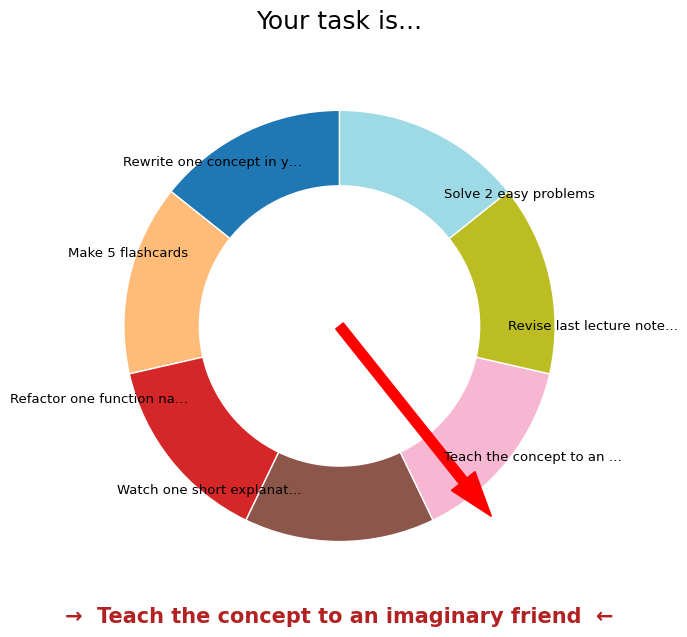

[DEBUG] Wheel plotted successfully

[Agent] Respect. Keep going 🔥


KeyError: 'Make 5 flashcards'

In [24]:
MEMORY_FILE = "01_spin_wheel_memory.json"

def run_agent():
    env = Environment(MEMORY_FILE)
    memory = env.execute(Action("load_memory", {}), {})["memory"] or {}

    Tools.notify("Spin-the-Wheel Task Picker")
    Tools.notify("Commands: spin | add ... | remove ... | favorite ... | hate ... | list | stop")

    user_text = Tools.ask("Ready? (type spin or a command)")

    while True:
        cmd_lower = user_text.strip().lower()

        if should_stop(cmd_lower):
            env.execute(Action("save_memory", {}), memory)
            Tools.notify("Saved. See you next time!")
            break

        # ─── Task management commands ─────────────────────────────────────
        if cmd_lower.startswith(("add", "remove", "favorite", "hate", "list", "ls", "show")):
            msg = manage_tasks(memory, user_text)
            if msg:
                Tools.notify(msg)
            env.execute(Action("save_memory", {}), memory)
            user_text = Tools.ask("Next command / spin?")
            continue

        # ─── Default: spin the wheel ──────────────────────────────────────
        task, count = pick_task_biased(memory)
        msg = f"→ {task}\n\n10 focused minutes!\n(picked {count} time{'s' if count != 1 else ''})"
        Tools.notify(msg)

        # Show wheel (graphical or text fallback)
        try:
            tasks = memory.get("tasks", [])
            if not tasks:
                raise ValueError("No tasks in memory")
            
            idx = tasks.index(task)  # find position of chosen task
            show_wheel(tasks, idx)
        
        except Exception as e:
            Tools.notify(f"(Graphical wheel failed: {str(e)})")
            
            # Text-based fallback wheel
            Tools.notify("Text wheel simulation:")
            print("      ┌───────────────┐")
            print("   ┌──┘               └──┐")
            for i, t in enumerate(tasks):
                prefix = "→ " if i == idx else "  "
                print(f"   │   {prefix}{t[:30]:<30}   │")
            print("   └──┐               ┌──┘")
            print("      └───────────────┘")
            print(f"             ↓ {task} ↓")

        # ─── Completion feedback ──────────────────────────────────────────
        resp = Tools.ask("Finished? (yes / no / skip)")
        feedback = handle_completion(memory, task, resp)
        Tools.notify(feedback)

        # Save after every meaningful action
        env.execute(Action("save_memory", {}), memory)

        user_text = Tools.ask("Again? (spin / command / stop)")

run_agent()

## Easy extensions

- Let students add/remove tasks during runtime.
- Add difficulty tags (easy/medium/hard).
- Print a small leaderboard of most-picked tasks.